# 数据可视化汇总

本笔记本整合了所有可视化内容，用于论文图表生成：
1. 建筑负荷数据可视化
2. 特征相关性分析
3. 迁移学习结果可视化

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 从 src 模块导入共享配置
from src import (
    BASE_DIR,
    BUILDINGS_DIR,
    BUILDINGS,
    SOURCE_BUILDING,
    TARGET_BUILDING,
    TARGET_SAMPLE_START,
    TARGET_SAMPLE_END,
    FIGURES_DIR,
    TARGET_COL,
    TIME_COL,
    setup_plot_style,
)

setup_plot_style()

## 一、负荷数据可视化

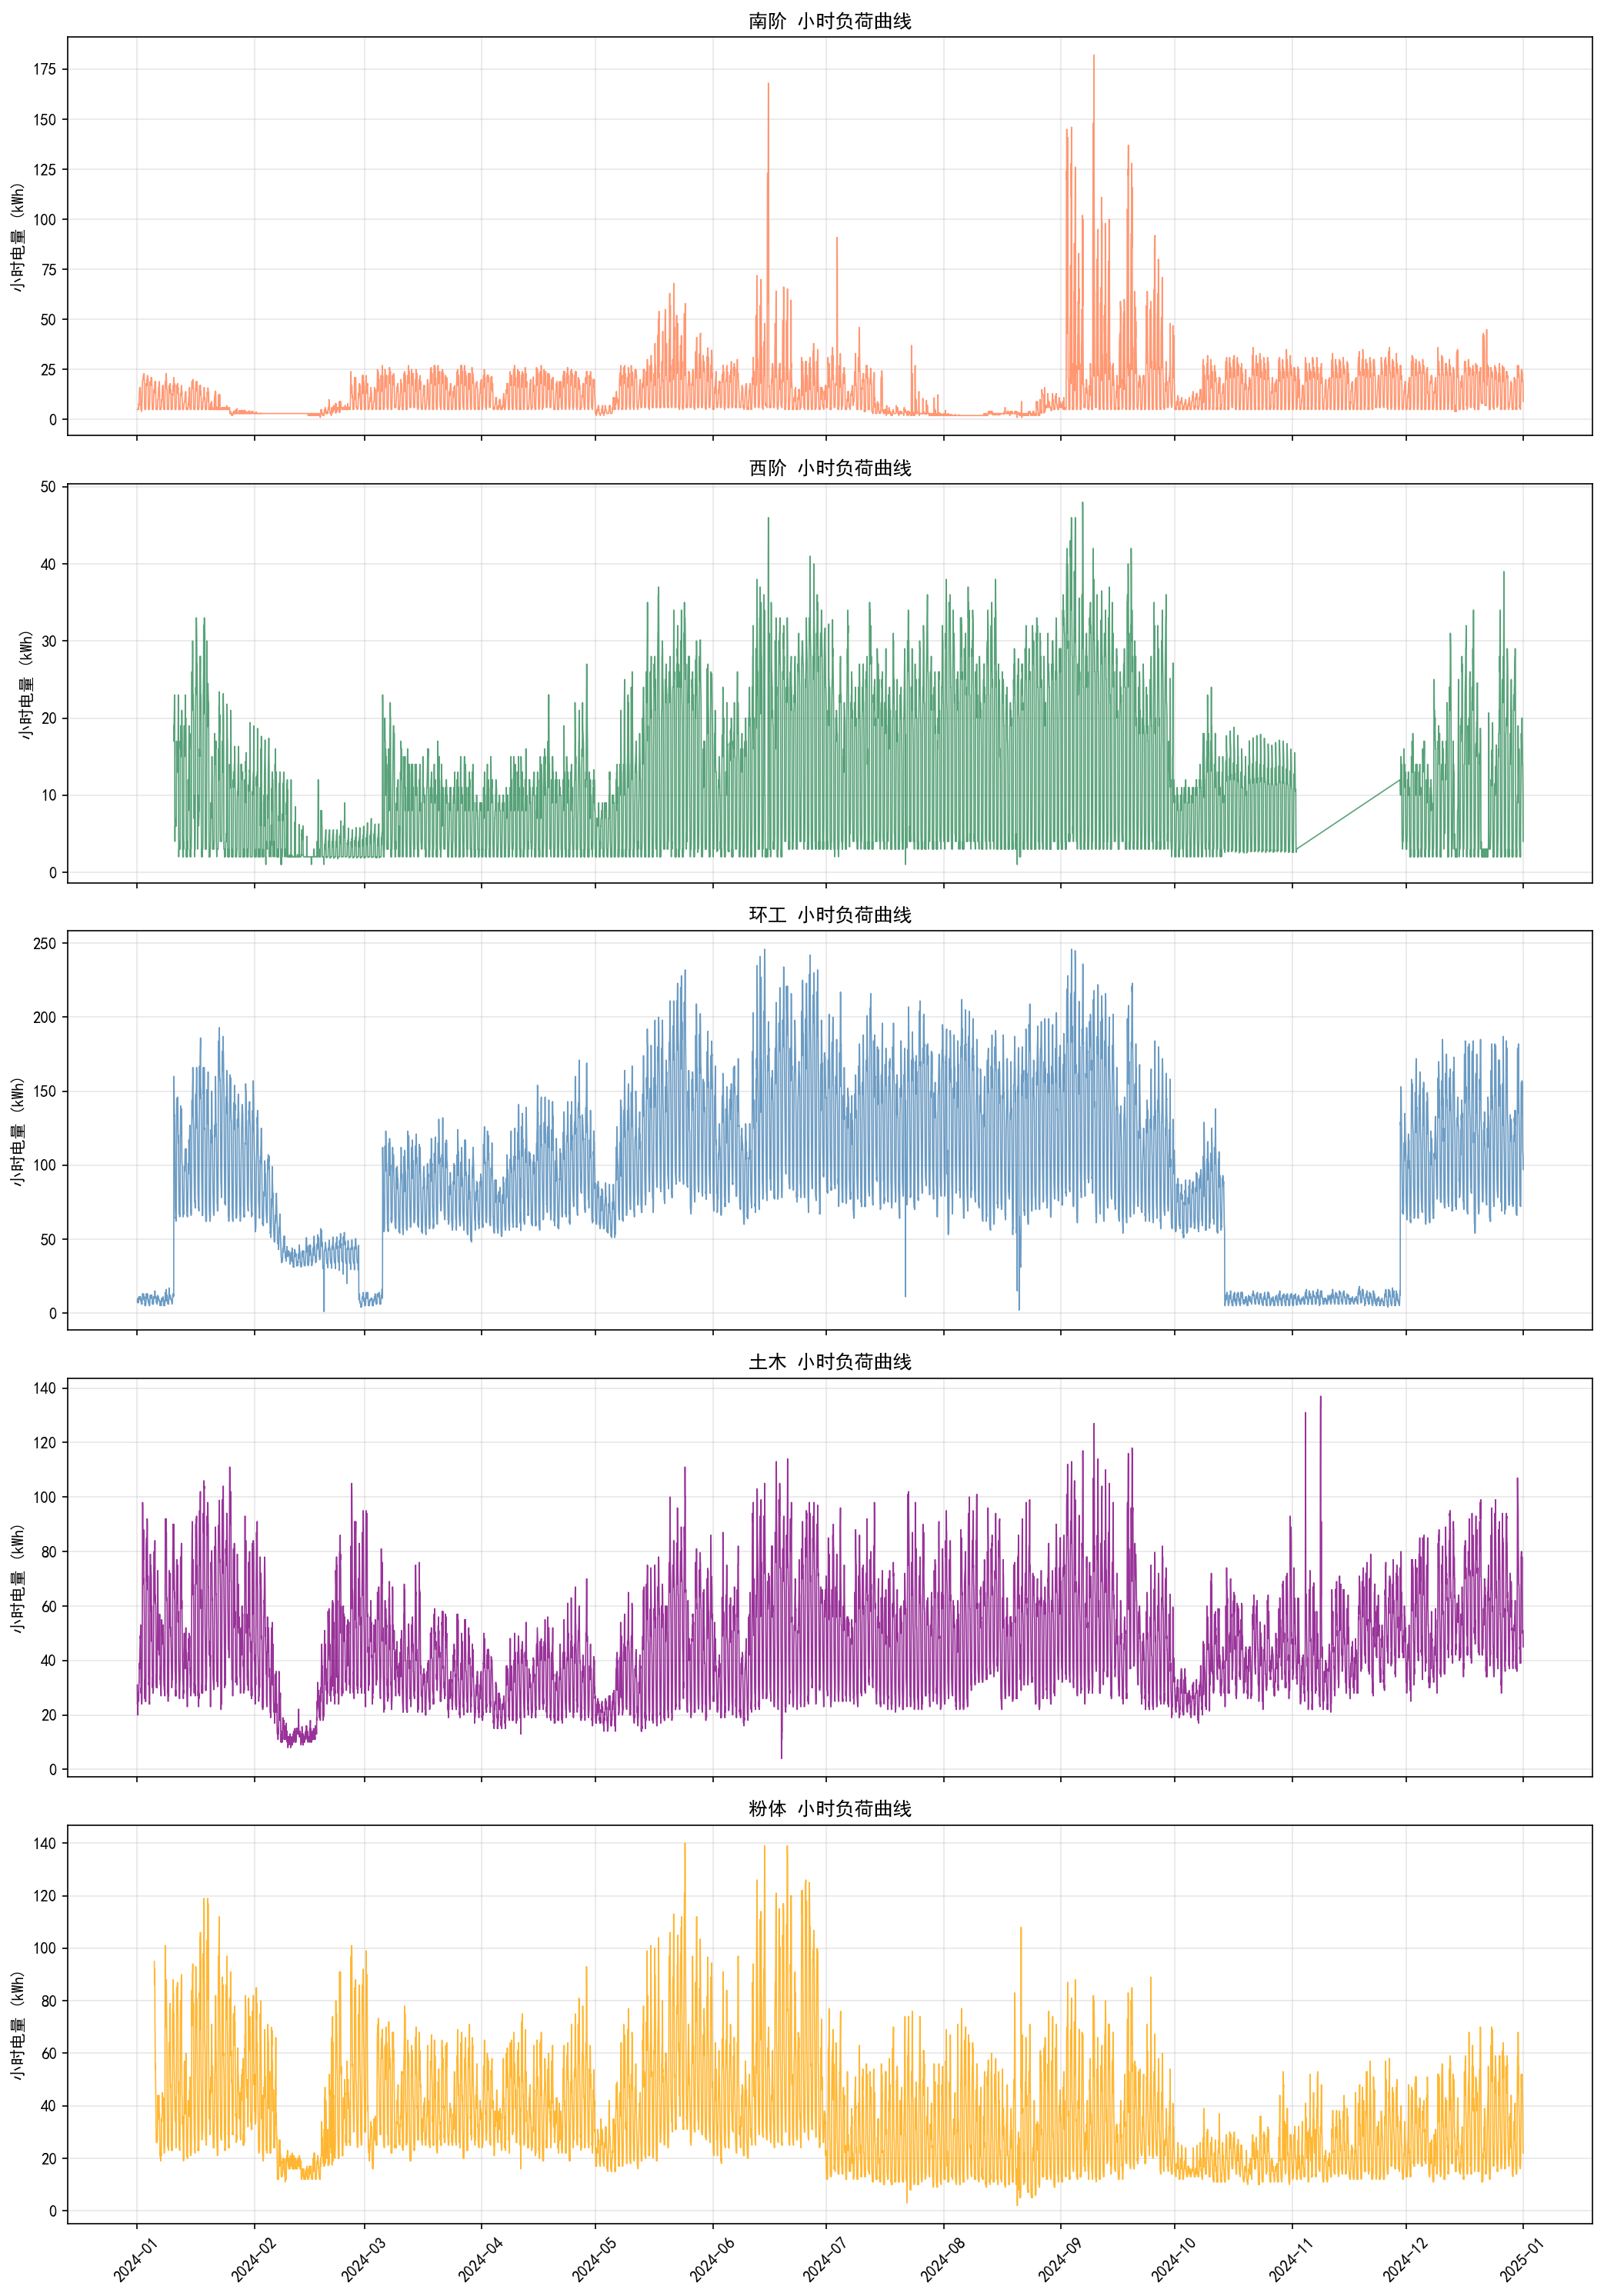

In [2]:
# 加载所有建筑的预处理后负荷数据
load_data_dict = {}
for name in BUILDINGS:
    path = BUILDINGS_DIR / f'{name}_预处理后.csv'
    if path.exists():
        df = pd.read_csv(path, parse_dates=[TIME_COL])
        df.set_index(TIME_COL, inplace=True)
        load_data_dict[name] = df

# 绘制所有建筑的小时负荷对比
fig, axes = plt.subplots(len(load_data_dict), 1, figsize=(14, 4*len(load_data_dict)), sharex=True)

if len(load_data_dict) == 1:
    axes = [axes]

colors = ['coral', 'seagreen', 'steelblue', 'purple', 'orange']

for i, (name, df) in enumerate(load_data_dict.items()):
    ax = axes[i]
    ax.plot(df.index, df[TARGET_COL], color=colors[i % len(colors)], 
            linewidth=0.8, alpha=0.8)
    ax.set_ylabel('小时电量 (kWh)')
    ax.set_title(f'{name} 小时负荷曲线')
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
# 不保存为图片
plt.show()

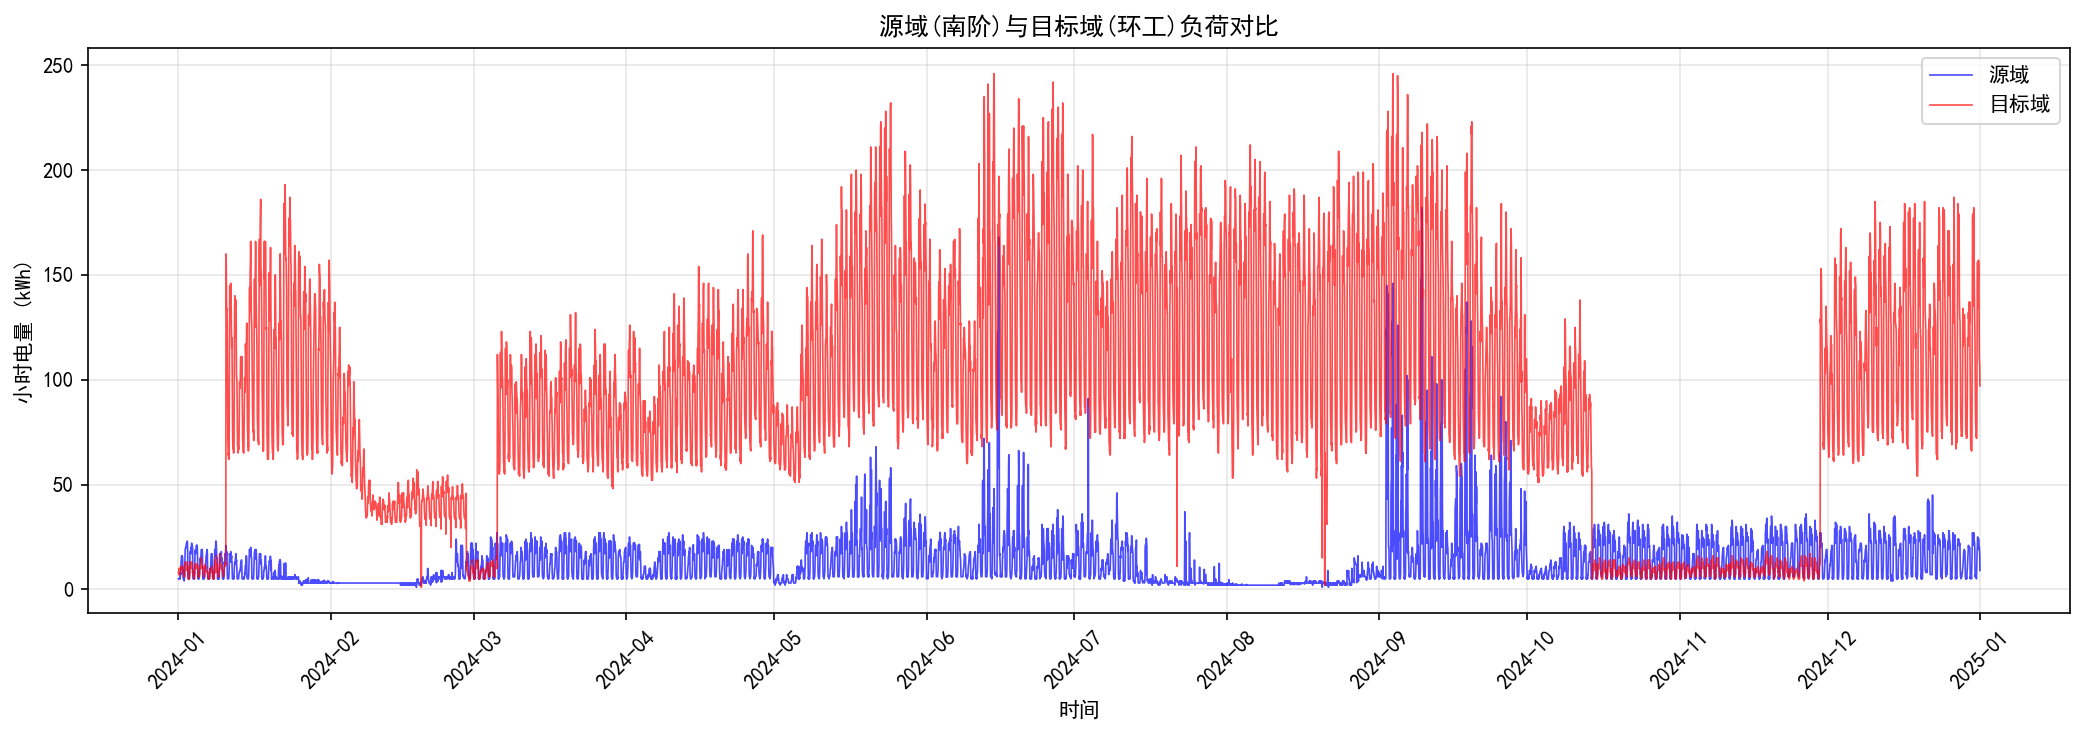

In [3]:
# 源域与目标域负荷对比
if SOURCE_BUILDING in load_data_dict and TARGET_BUILDING in load_data_dict:
    fig, ax = plt.subplots(figsize=(14, 5))
    
    source_df = load_data_dict[SOURCE_BUILDING]
    target_df = load_data_dict[TARGET_BUILDING]
    
    ax.plot(source_df.index, source_df[TARGET_COL], 'b-', 
            linewidth=0.8, alpha=0.7, label="源域")
    ax.plot(target_df.index, target_df[TARGET_COL], 'r-', 
            linewidth=0.8, alpha=0.7, label="目标域")
    
    ax.set_xlabel('时间')
    ax.set_ylabel('小时电量 (kWh)')
    ax.set_title(f'源域({SOURCE_BUILDING})与目标域({TARGET_BUILDING})负荷对比')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    # 不保存为图片
    plt.show()

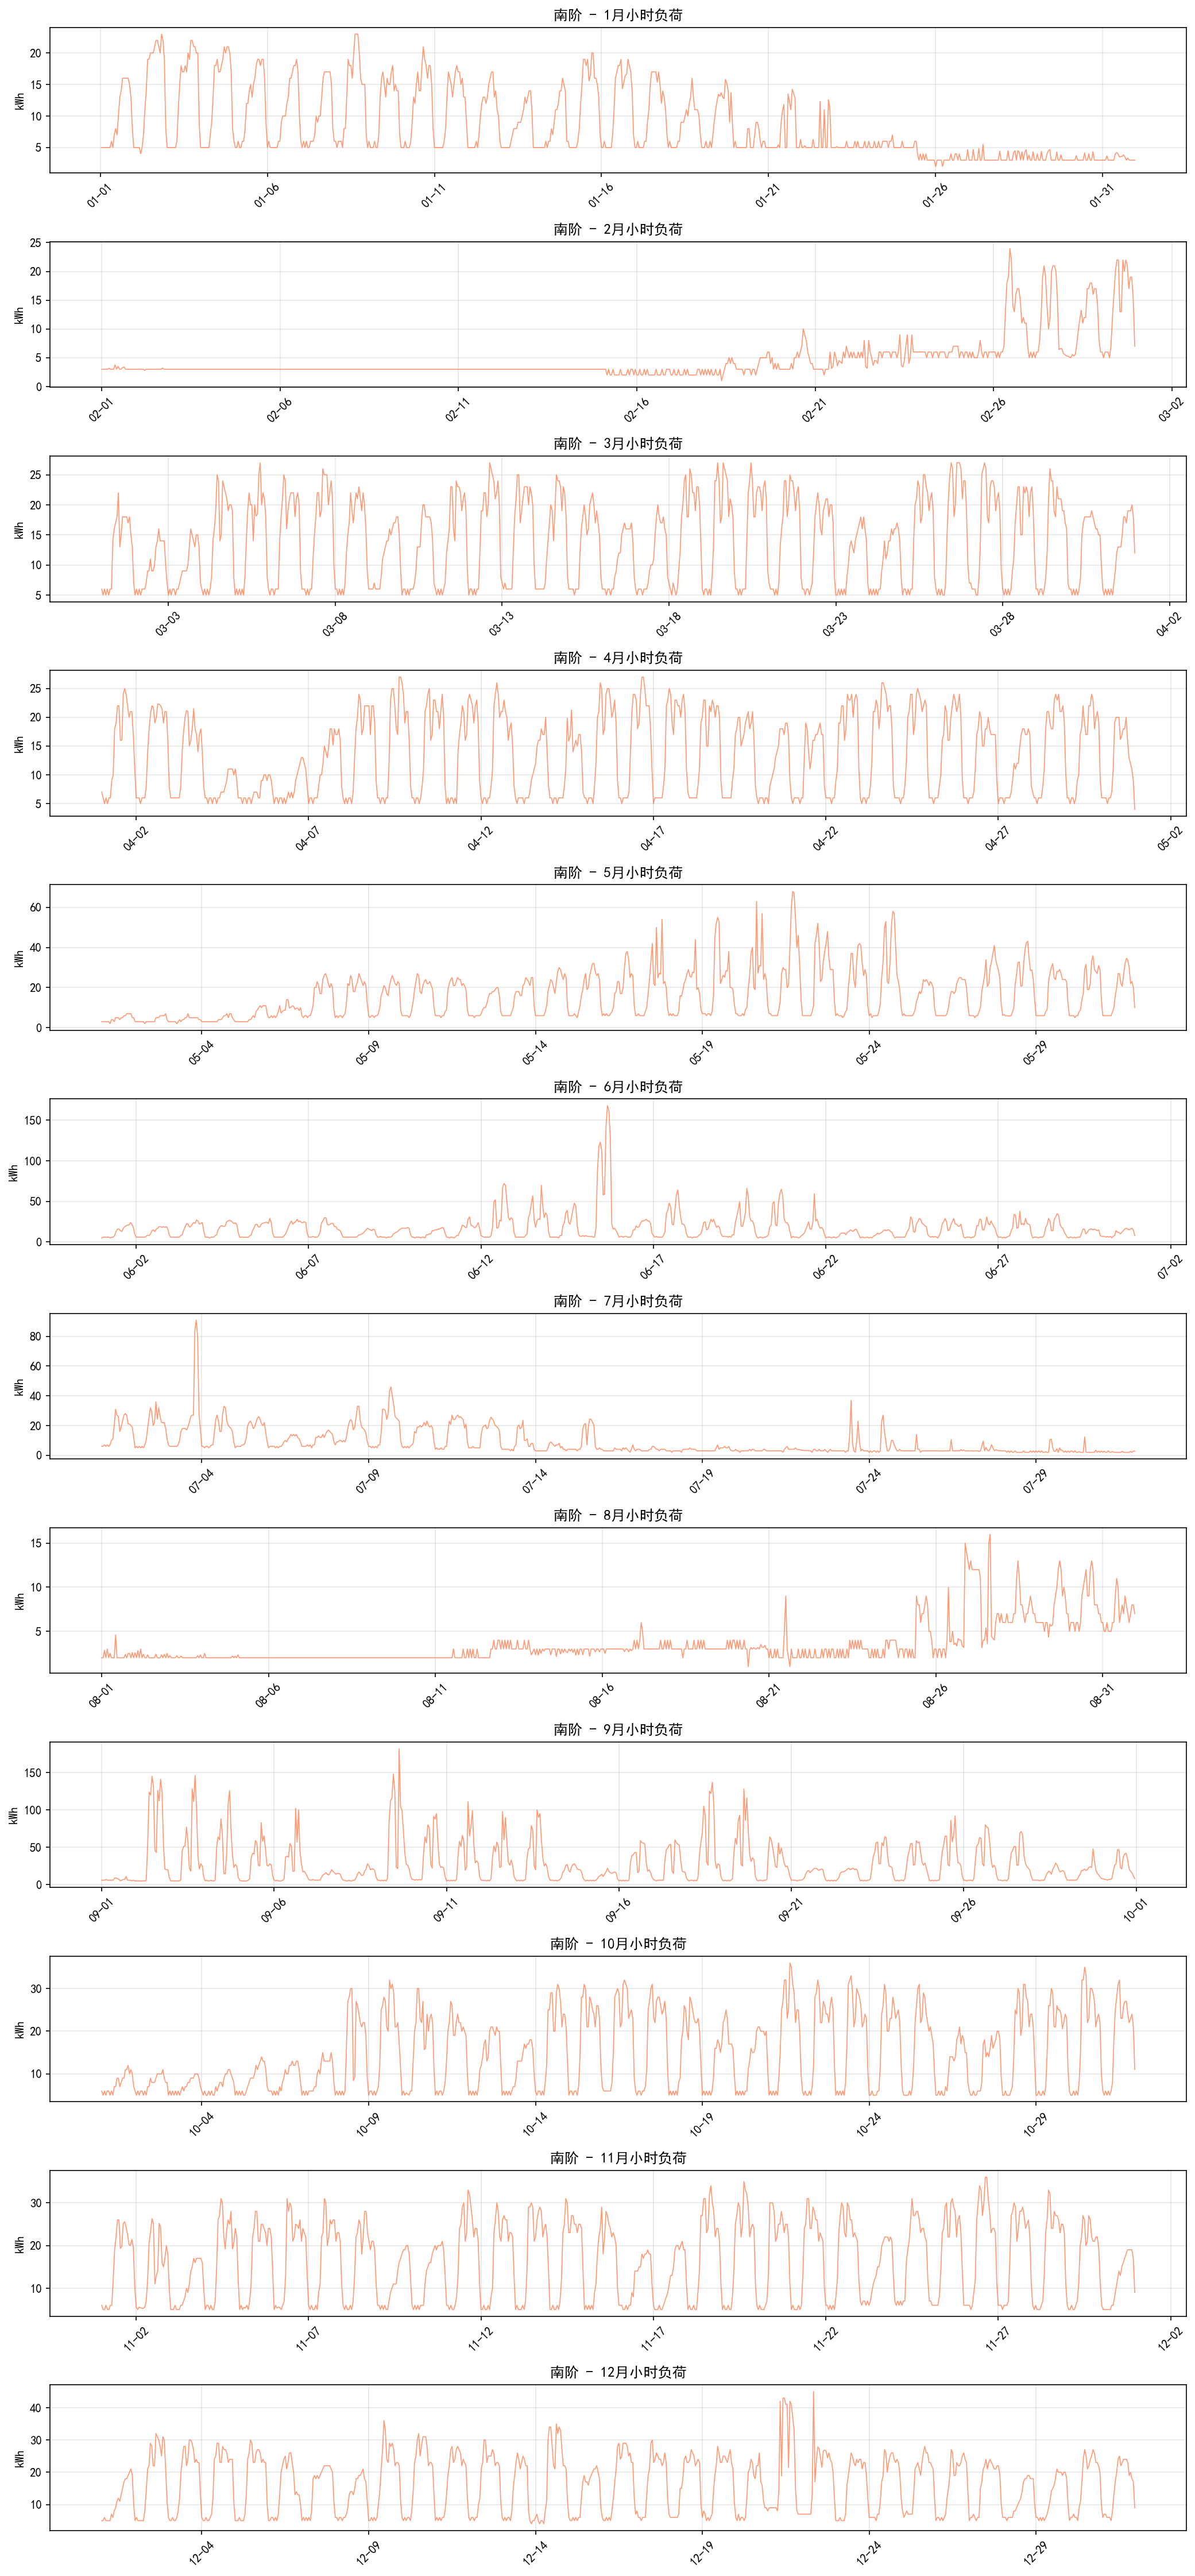

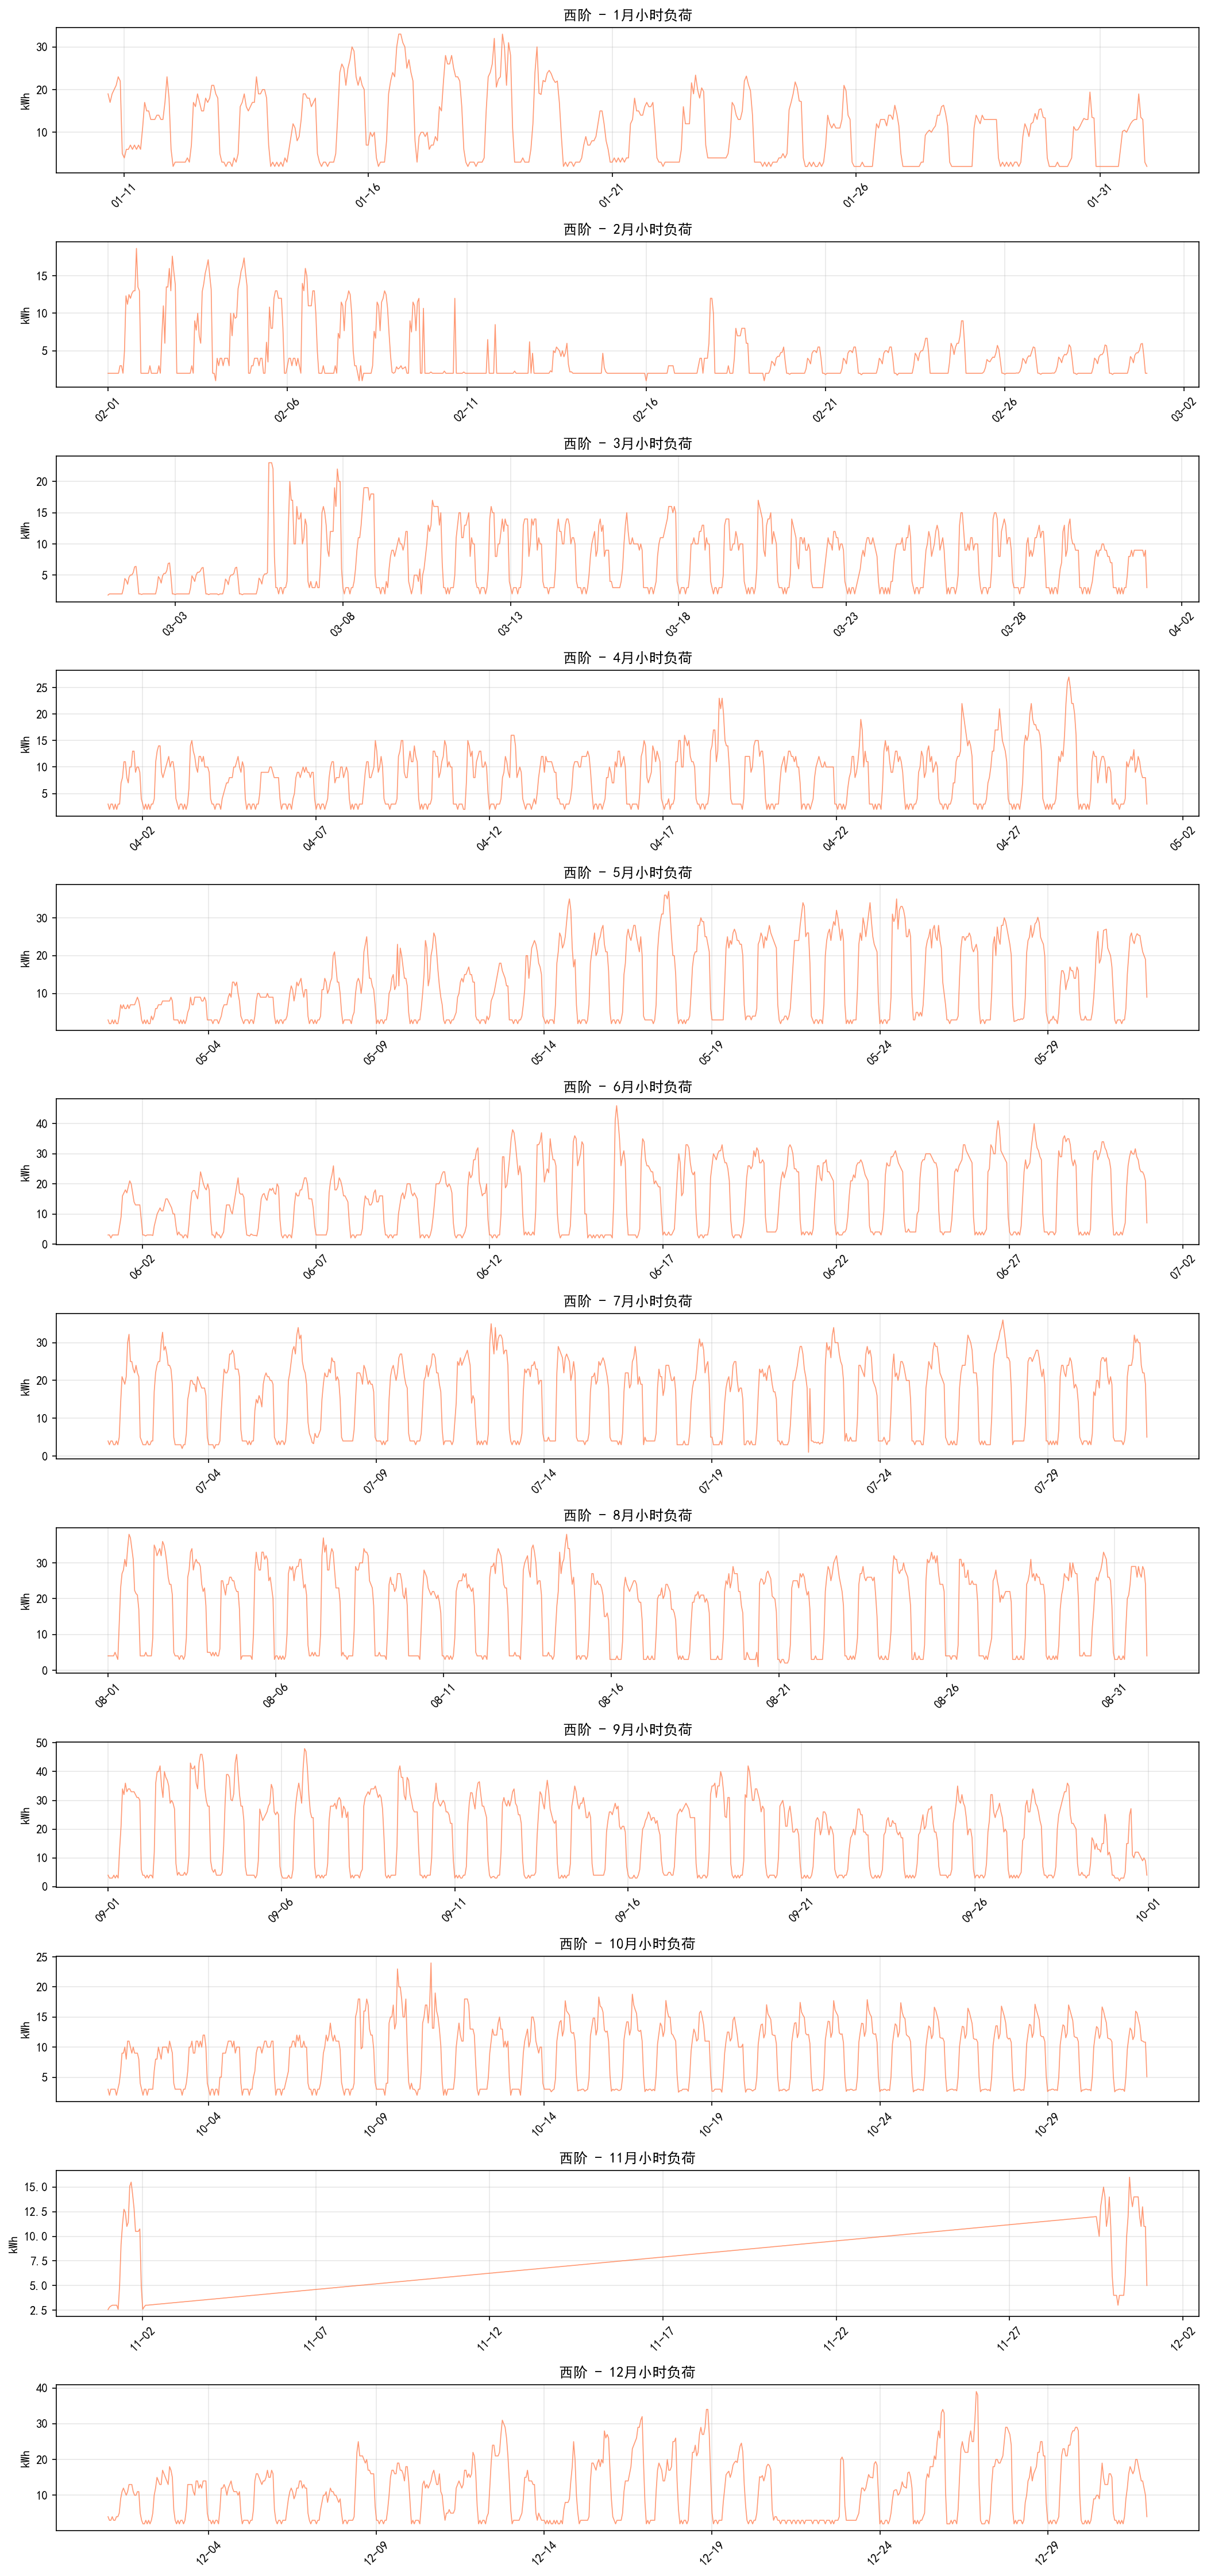

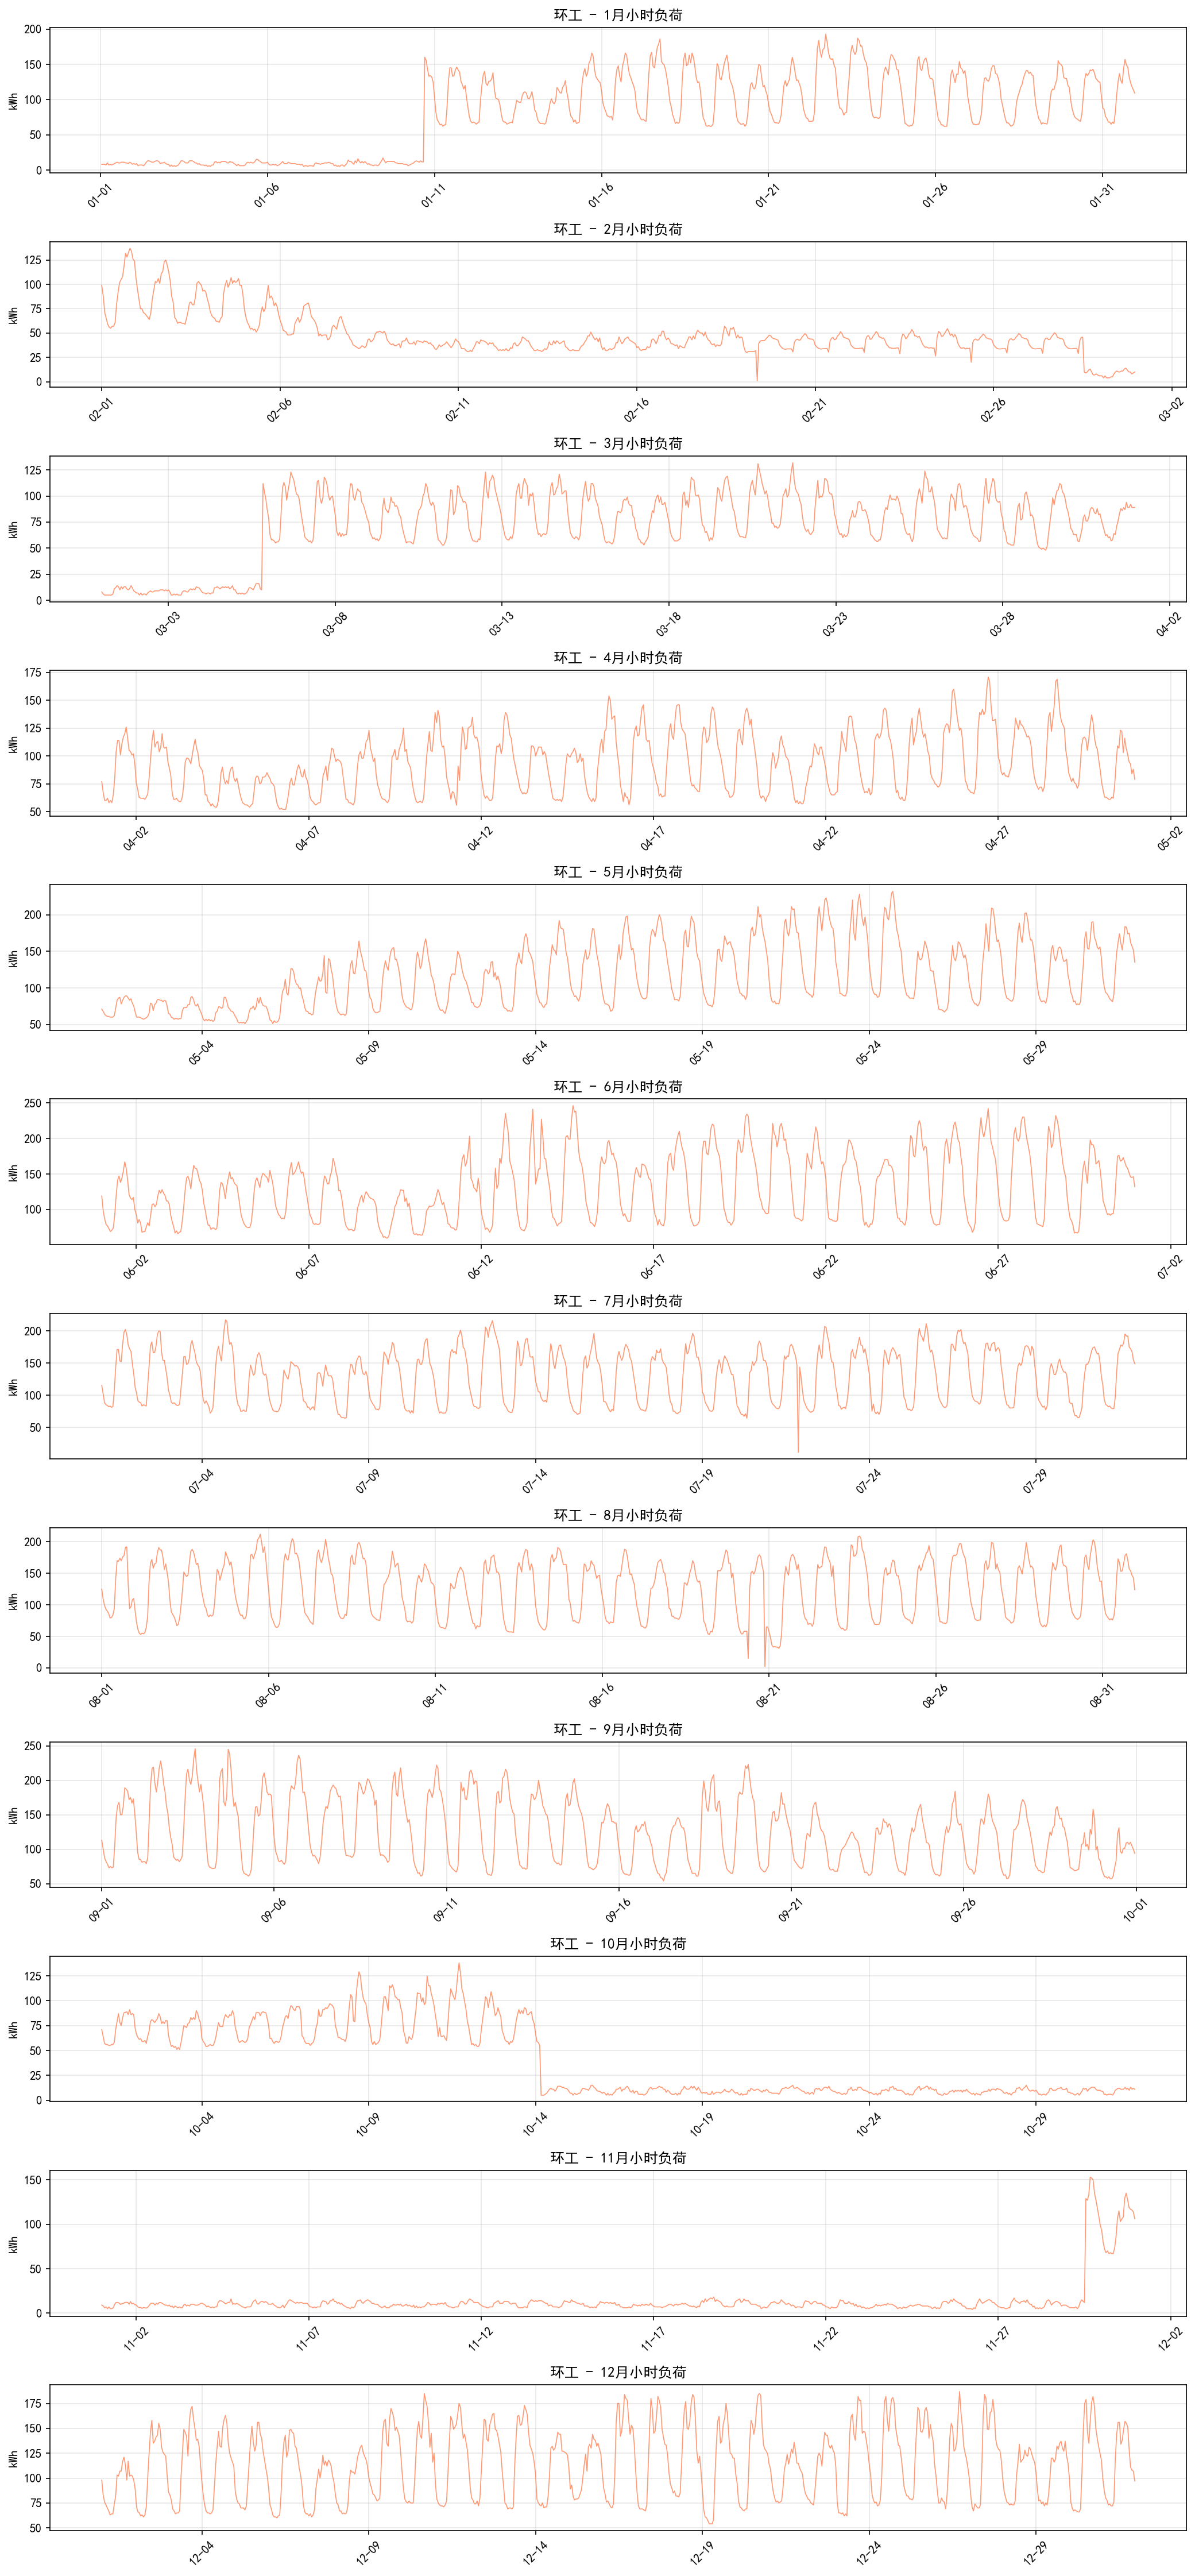

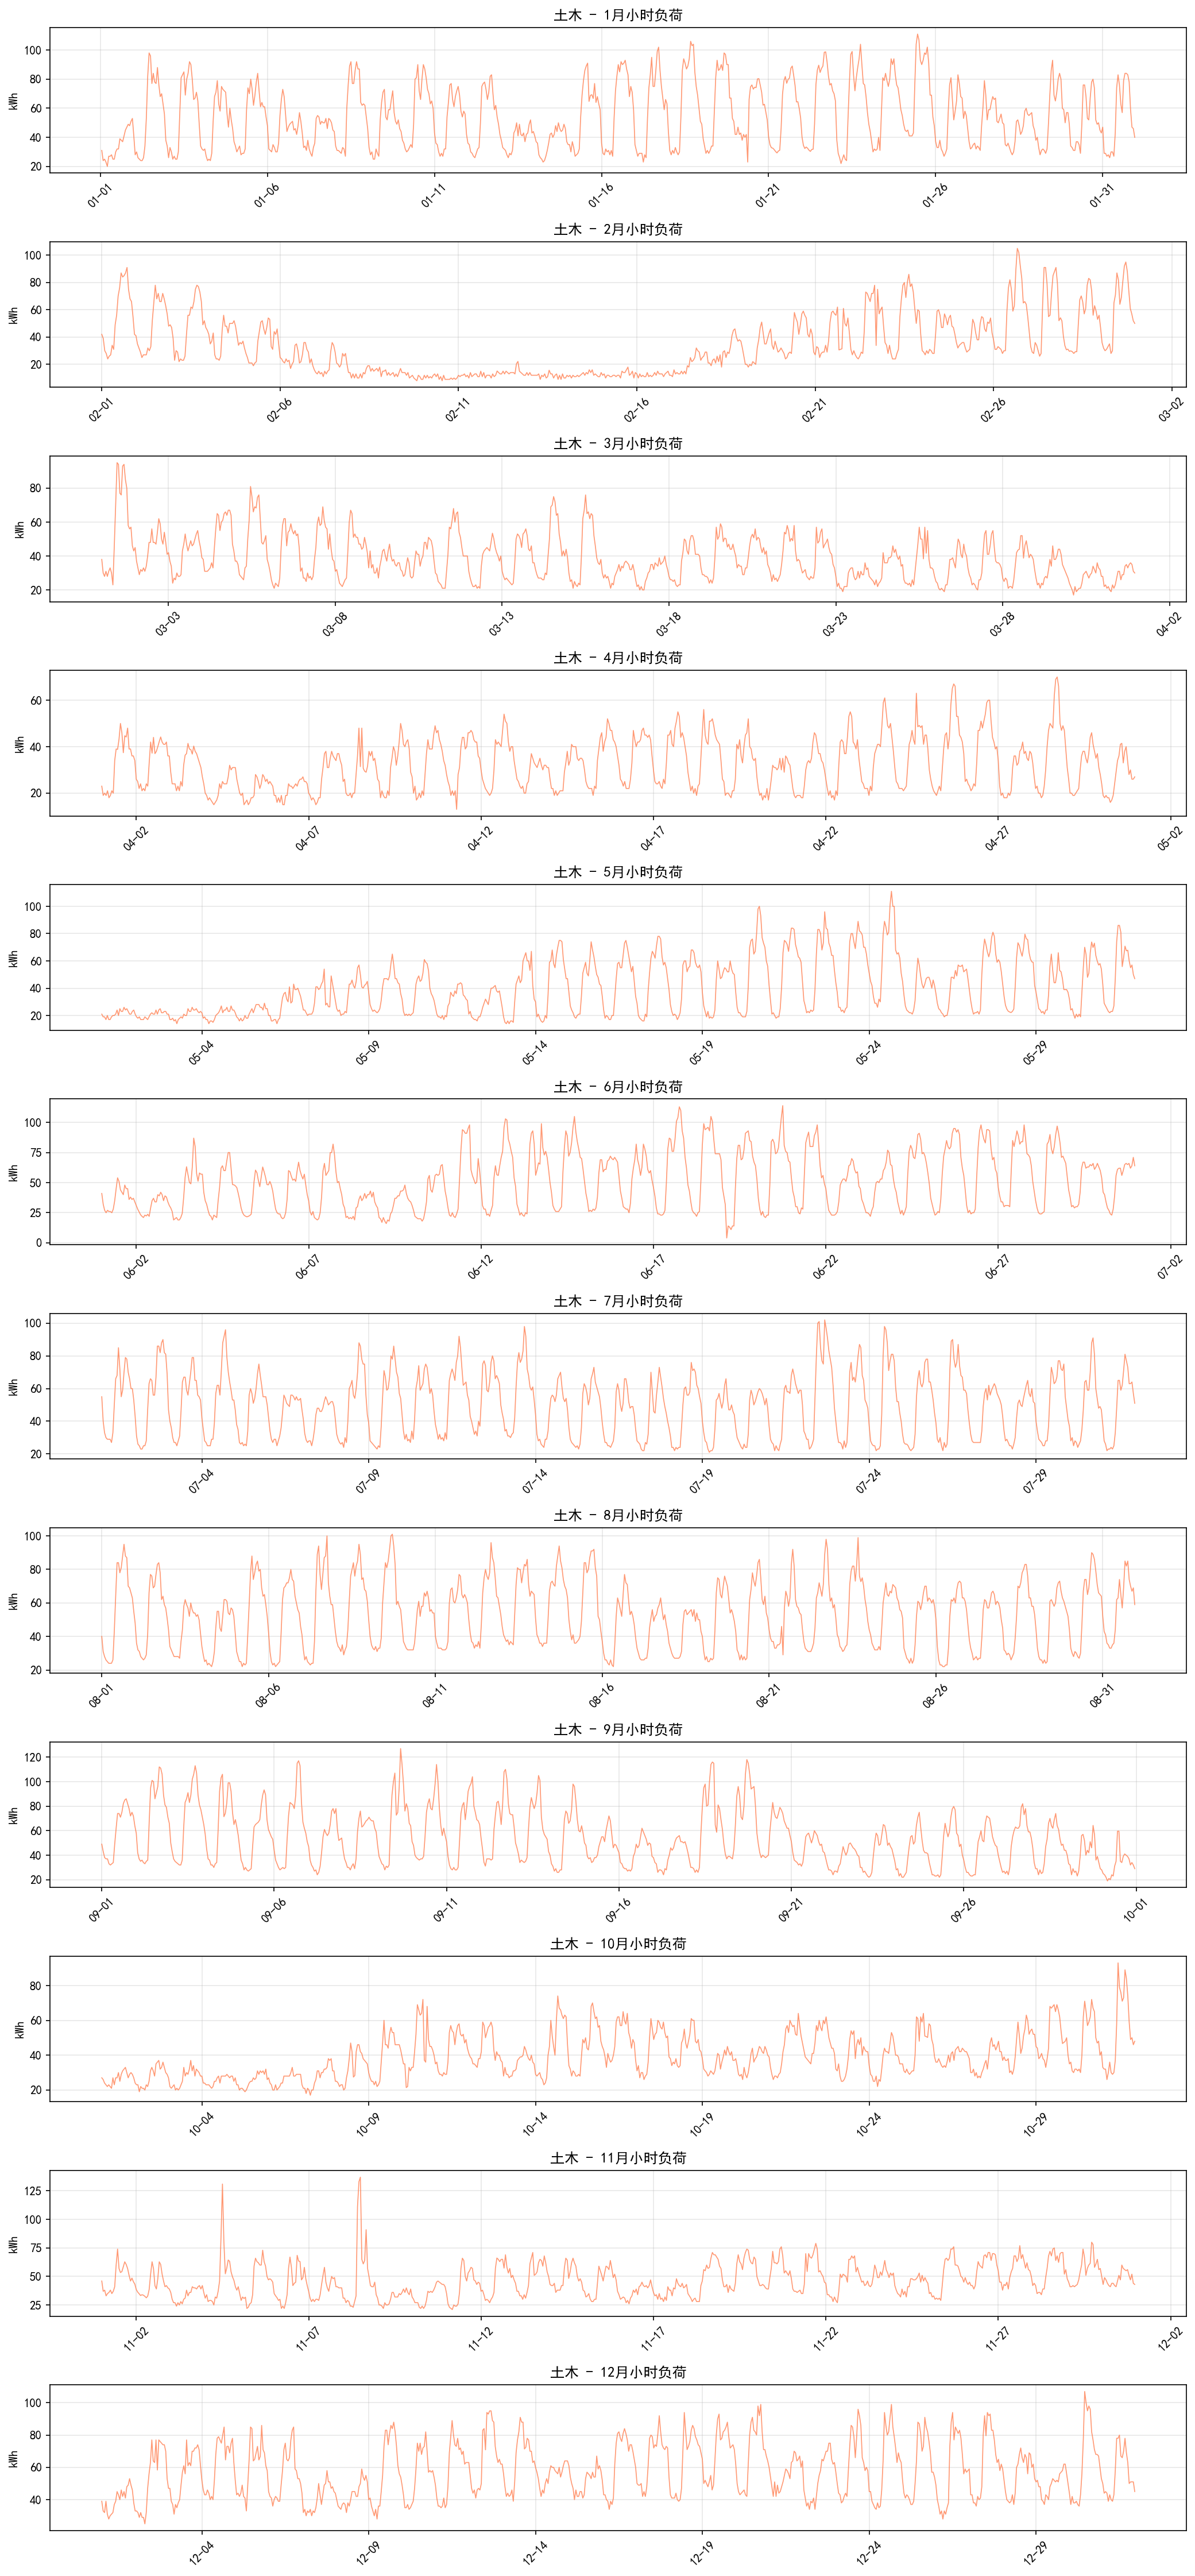

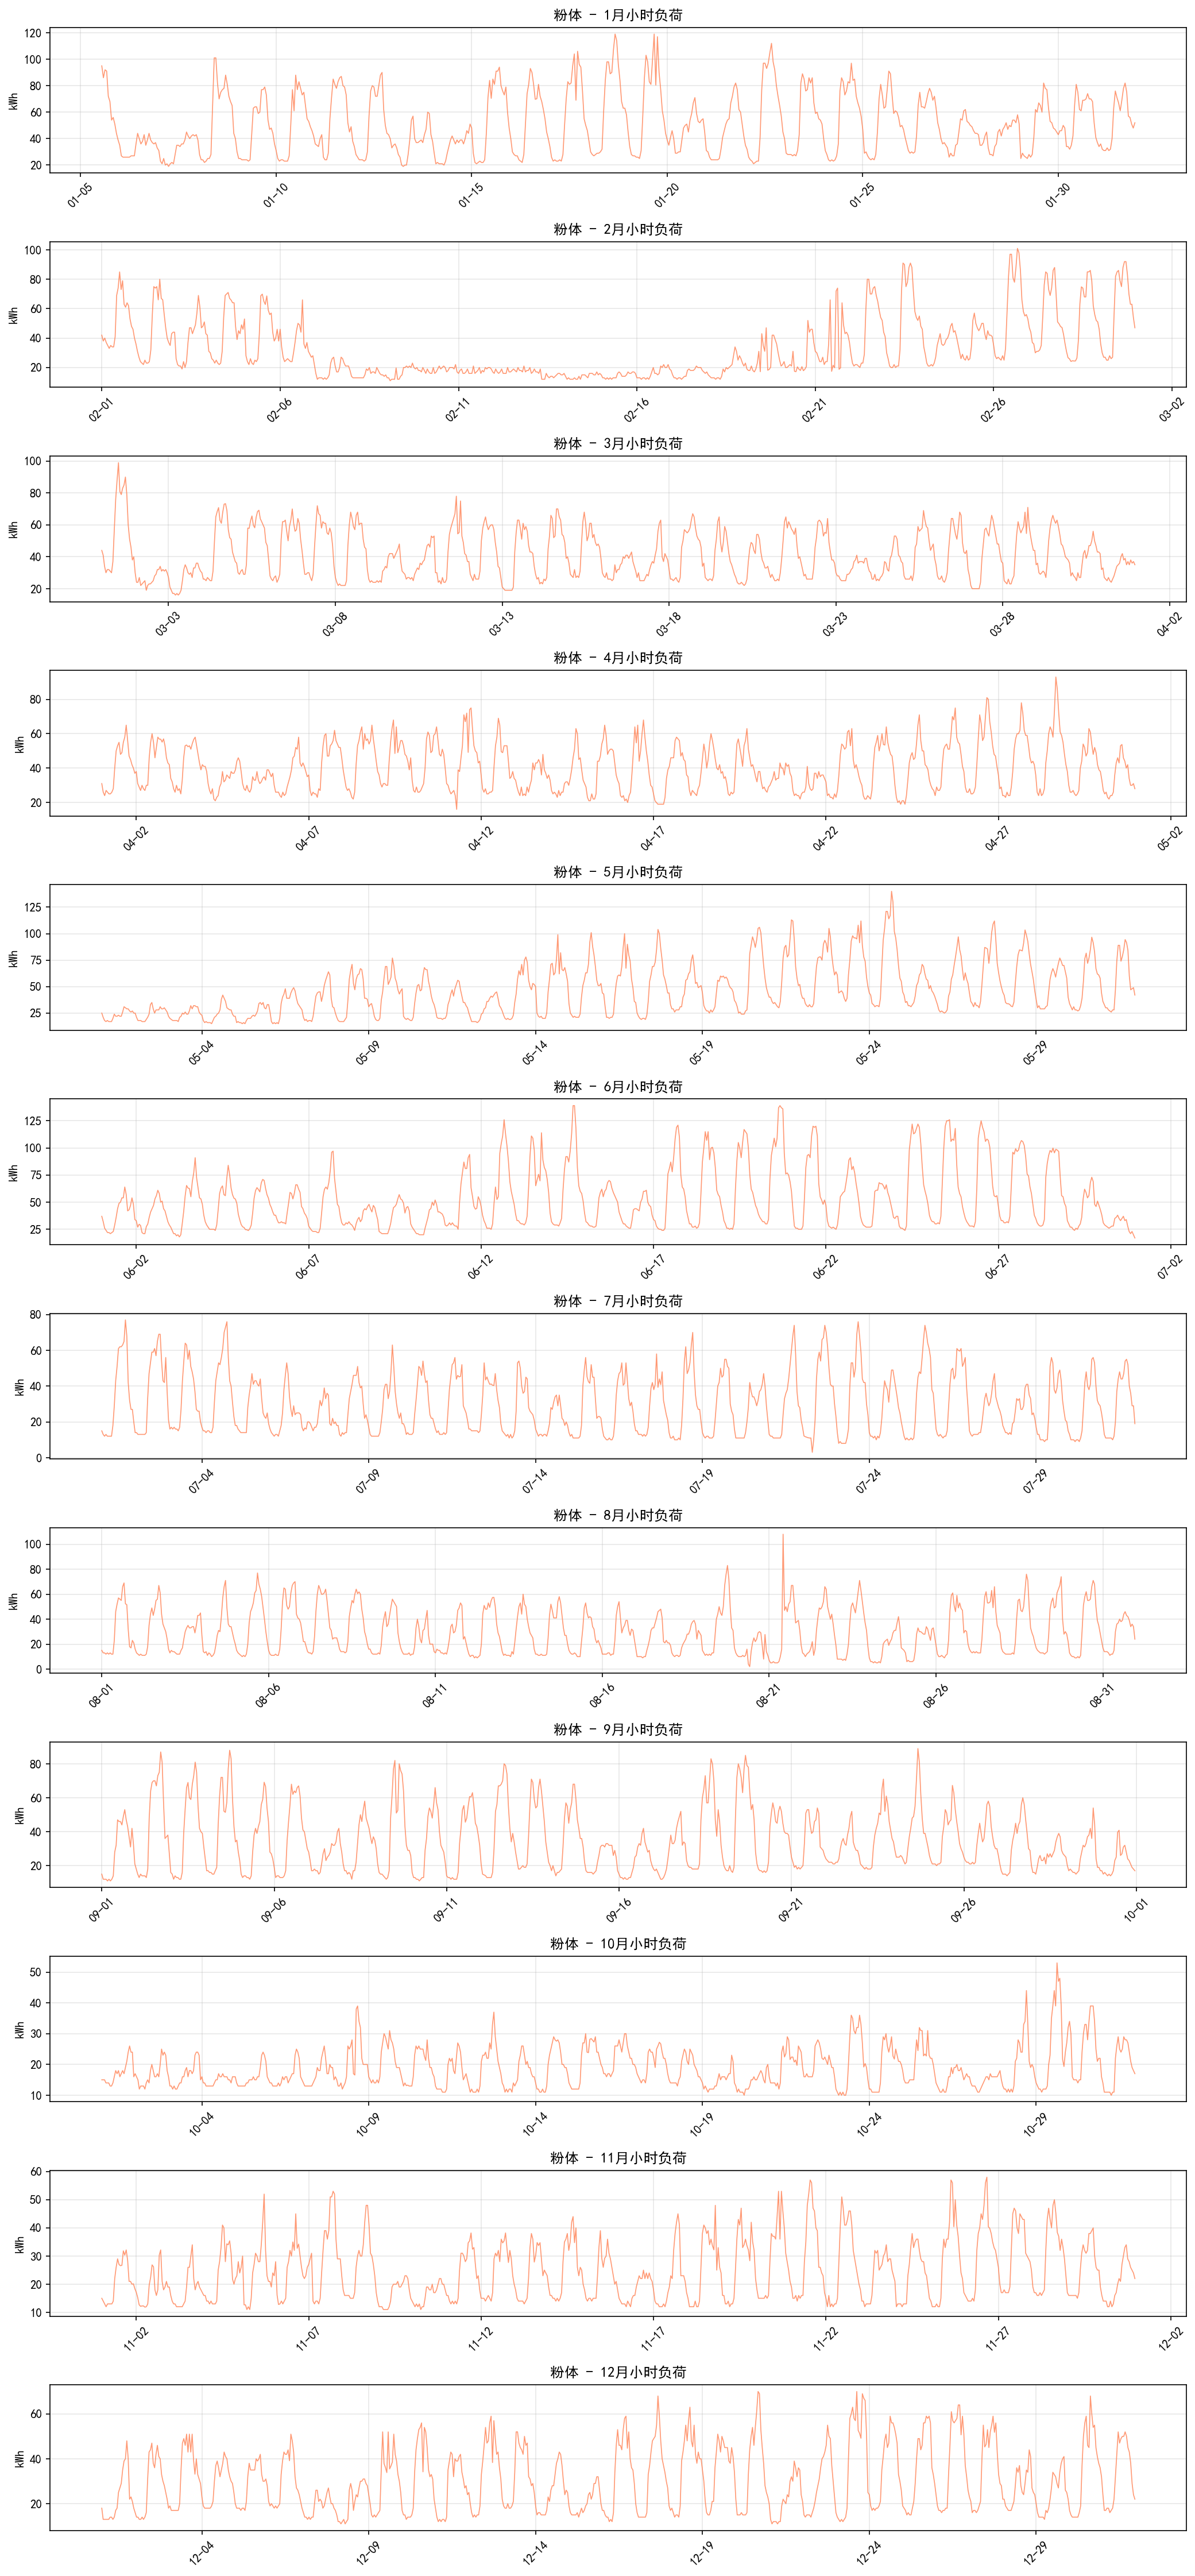

In [4]:
# 按月展示负荷曲线
for name, df in load_data_dict.items():
    df_monthly = df.copy()
    df_monthly['month'] = df_monthly.index.month
    months = sorted(df_monthly['month'].unique())
    n_months = len(months)
    
    fig, axes = plt.subplots(n_months, 1, figsize=(14, 2.5*n_months), sharex=False)
    if n_months == 1:
        axes = [axes]
    
    for i, month in enumerate(months):
        month_data = df_monthly[df_monthly['month'] == month]
        axes[i].plot(month_data.index, month_data[TARGET_COL], 
                     color='coral', linewidth=0.8, alpha=0.8)
        axes[i].set_title(f'{name} - {month}月小时负荷')
        axes[i].set_ylabel('kWh')
        axes[i].grid(True, alpha=0.3)
        
        axes[i].xaxis.set_major_locator(mdates.DayLocator(interval=5))
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        axes[i].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    # 不保存为图片
    plt.show()

## 二、特征相关性分析

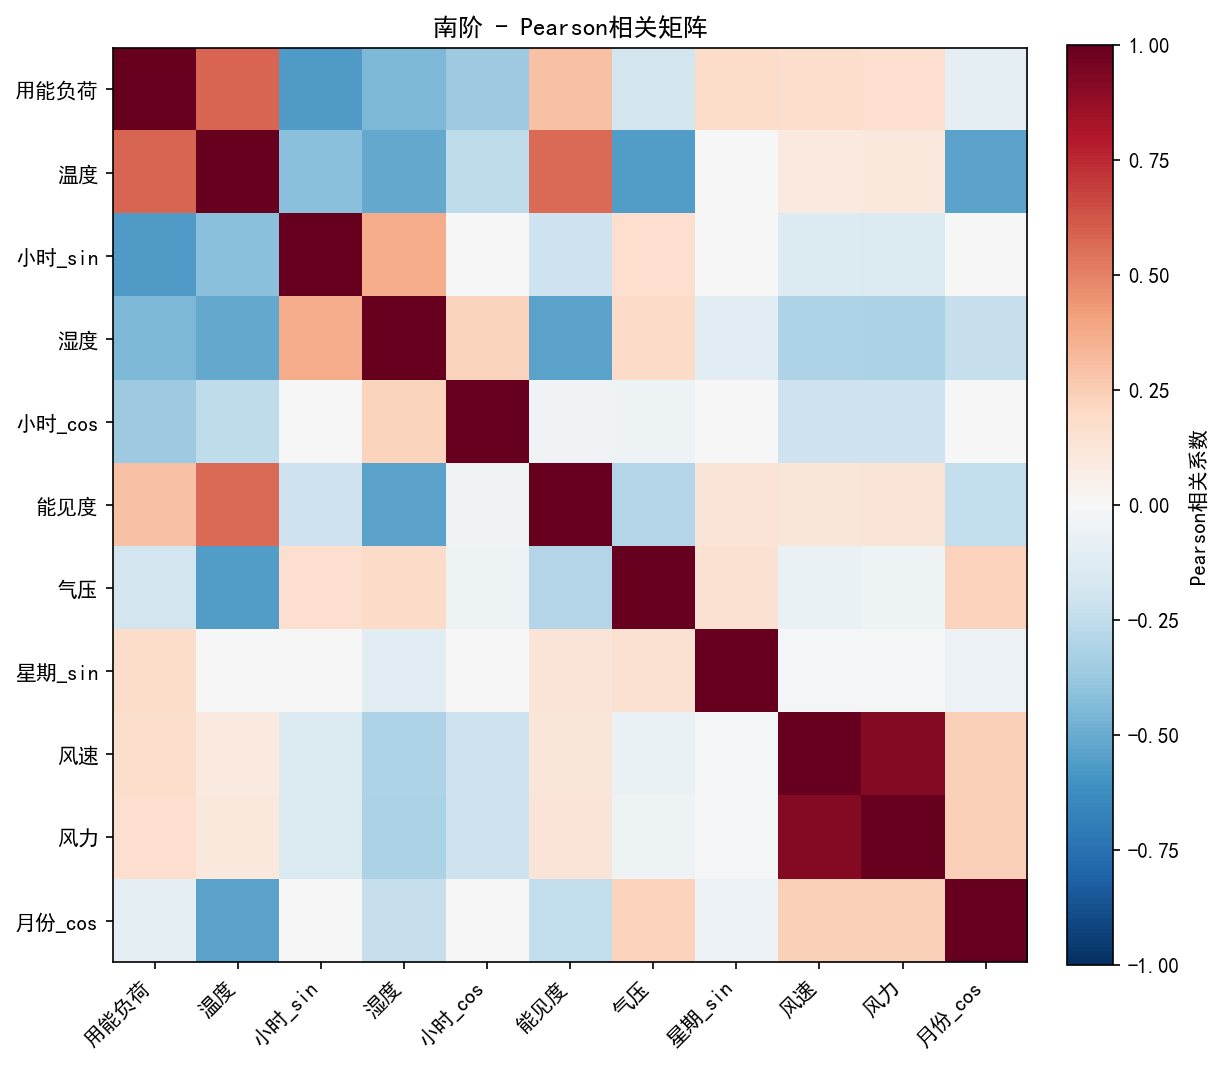

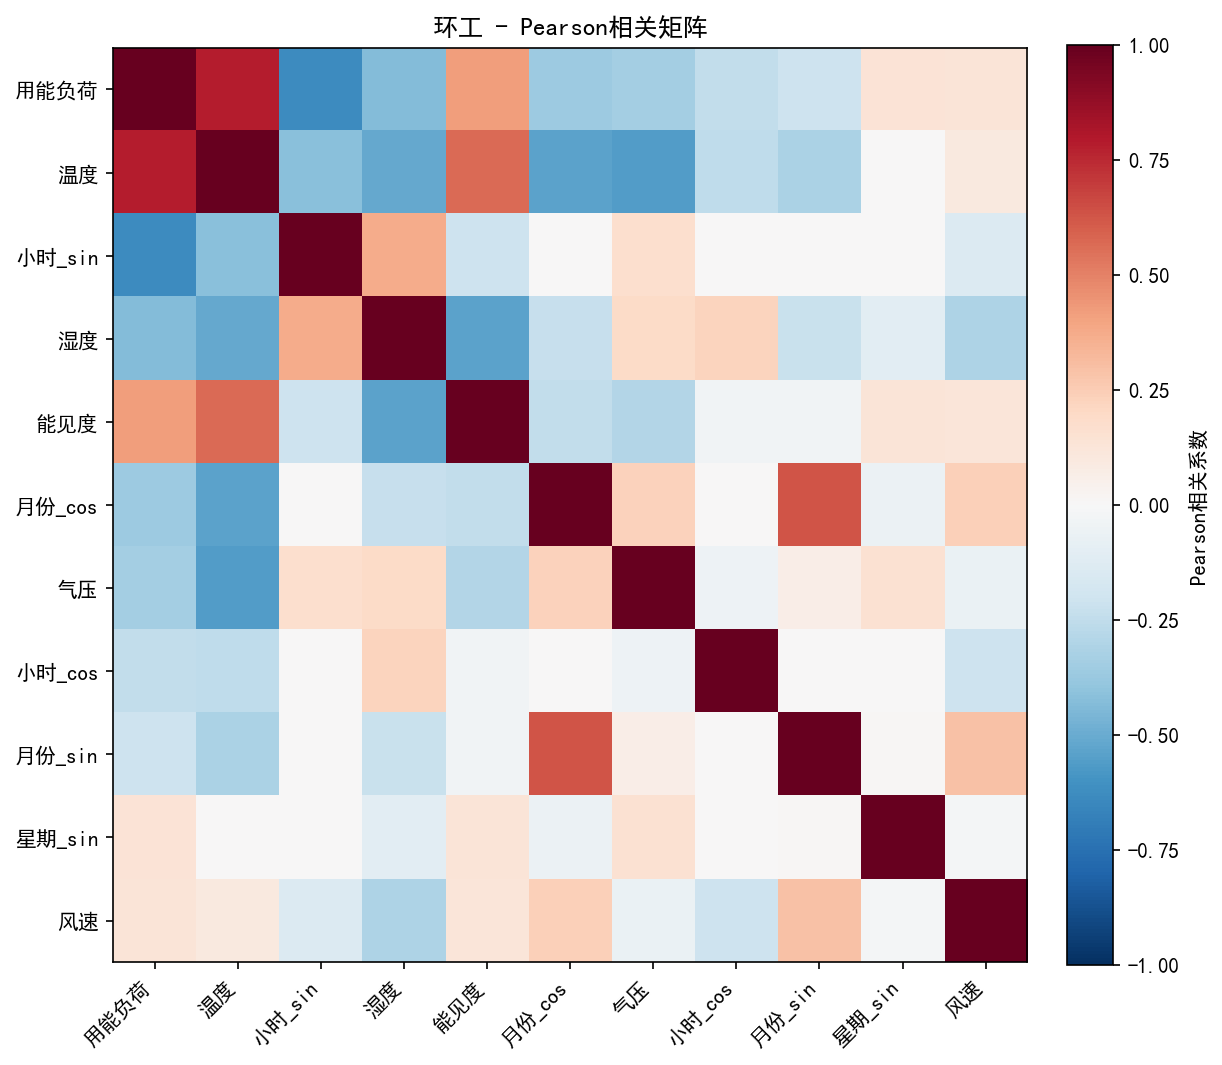

In [5]:
# 加载特征数据，仅保留源域和目标域
feature_data_dict = {}
for name in [SOURCE_BUILDING, TARGET_BUILDING]:
    path = BUILDINGS_DIR / f'{name}_特征.csv'
    if path.exists():
        df = pd.read_csv(path, parse_dates=[TIME_COL])
        df.set_index(TIME_COL, inplace=True)
        feature_data_dict[name] = df

# 中文列名映射，便于论文呈现
feature_name_map = {
    TARGET_COL: '用能负荷',
    '温度(℃)': '温度',
    '风力(级)': '风力',
    '风速(km/h)': '风速',
    '气压(hPa)': '气压',
    '湿度(%)': '湿度',
    '能见度(km)': '能见度',
    '云量%': '云量',
    '是否降水': '是否降水',
    '降水量对数变换': '降水量对数',
    '天气状况_中雨': '天气状况_中雨',
    '天气状况_中雪': '天气状况_中雪',
    '天气状况_多云': '天气状况_多云',
    '天气状况_大雨': '天气状况_大雨',
    '天气状况_大雪': '天气状况_大雪',
    '天气状况_大雾': '天气状况_大雾',
    '天气状况_小雨': '天气状况_小雨',
    '天气状况_小雪': '天气状况_小雪',
    '天气状况_扬沙': '天气状况_扬沙',
    '天气状况_晴': '天气状况_晴',
    '天气状况_暴雨': '天气状况_暴雨',
    '天气状况_暴雪': '天气状况_暴雪',
    '天气状况_沙尘暴': '天气状况_沙尘暴',
    '天气状况_浮尘': '天气状况_浮尘',
    '天气状况_阴': '天气状况_阴',
    '天气状况_雨': '天气状况_雨',
    '天气状况_雾': '天气状况_雾',
    '天气状况_霾': '天气状况_霾',
    '风向_东北风': '风向_东北风',
    '风向_东南风': '风向_东南风',
    '风向_东风': '风向_东风',
    '风向_北风': '风向_北风',
    '风向_南风': '风向_南风',
    '风向_微风': '风向_微风',
    '风向_西北风': '风向_西北风',
    '风向_西南风': '风向_西南风',
    '风向_西风': '风向_西风',
    '风向_静风': '风向_静风',
    'is_holiday': '是否节假日',
    'hour_sin': '小时_sin',
    'hour_cos': '小时_cos',
    'day_of_week_sin': '星期_sin',
    'day_of_week_cos': '星期_cos',
    'month_sin': '月份_sin',
    'month_cos': '月份_cos',
}

sample_start = pd.to_datetime(TARGET_SAMPLE_START)
sample_end = pd.to_datetime(TARGET_SAMPLE_END)

# 特征相关性分析：按源域/目标域在小样本时间段内绘制 Pearson 相关矩阵
for name, df in feature_data_dict.items():
    sample_df = df.loc[(df.index >= sample_start) & (df.index < sample_end)].copy()

    if sample_df.empty:
        print(f'{name}: 小样本时间段内无数据，跳过相关性热力图')
        continue

    # 获取所有数值列，排除原始离散时间/分箱列，保留 sin/cos 编码特征
    numeric_features = sample_df.select_dtypes(include=[np.number]).columns.tolist()
    exclude_cols = ['month', 'hour', 'temp_bin']
    numeric_features = [col for col in numeric_features if col not in exclude_cols]

    if TARGET_COL not in numeric_features:
        print(f'{name}: 未找到目标列 {TARGET_COL}，跳过相关性分析')
        continue

    corr_data = sample_df[numeric_features].copy()
    valid_features = [
        col for col in corr_data.columns
        if corr_data[col].notna().sum() > 1 and corr_data[col].nunique(dropna=True) > 1
    ]
    corr_data = corr_data[valid_features]

    if len(valid_features) < 2:
        print(f'{name}: 有效数值特征不足，跳过相关性热力图')
        continue

    target_corr = corr_data.corr(method='pearson')[TARGET_COL].drop(TARGET_COL).dropna()
    if target_corr.empty:
        print(f'{name}: 目标负荷与其它特征无可用相关系数，跳过热力图')
        continue

    top_features = target_corr.abs().sort_values(ascending=False).head(10).index.tolist()
    if len(top_features) < 2:
        print(f'{name}: 可展示的高相关特征不足，跳过热力图')
        continue

    corr_matrix = corr_data[[TARGET_COL] + top_features].corr(method='pearson')
    corr_matrix = corr_matrix.rename(index=feature_name_map, columns=feature_name_map)

    fig_size = max(8, 0.75 * len(corr_matrix.columns))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    cmap = plt.colormaps['RdBu_r'].copy()
    cmap.set_bad(color='#f2f2f2')

    heatmap = ax.imshow(corr_matrix, cmap=cmap, vmin=-1, vmax=1, aspect='equal')

    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.index)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr_matrix.index)
    ax.set_title(f'{name} - Pearson相关矩阵')

    cbar = fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Pearson相关系数')

    plt.tight_layout()
    # 不保存为图片
    plt.show()

## 三、迁移学习结果可视化

      策略       MAE      RMSE   CV-RMSE     MAPE       R2
    源域直测 11.997673 17.593866 14.888696 9.591714 0.811712
   目标域训练  9.237530 13.638567 11.541550 7.516170 0.886852
    全层微调  6.444602 10.638171  9.002484 5.231682 0.931229
冻结LSTM微调  8.145742 12.981802 10.985766 6.671669 0.897470
  冻结特征回归  6.771502 11.180850  9.461722 5.435625 0.924055


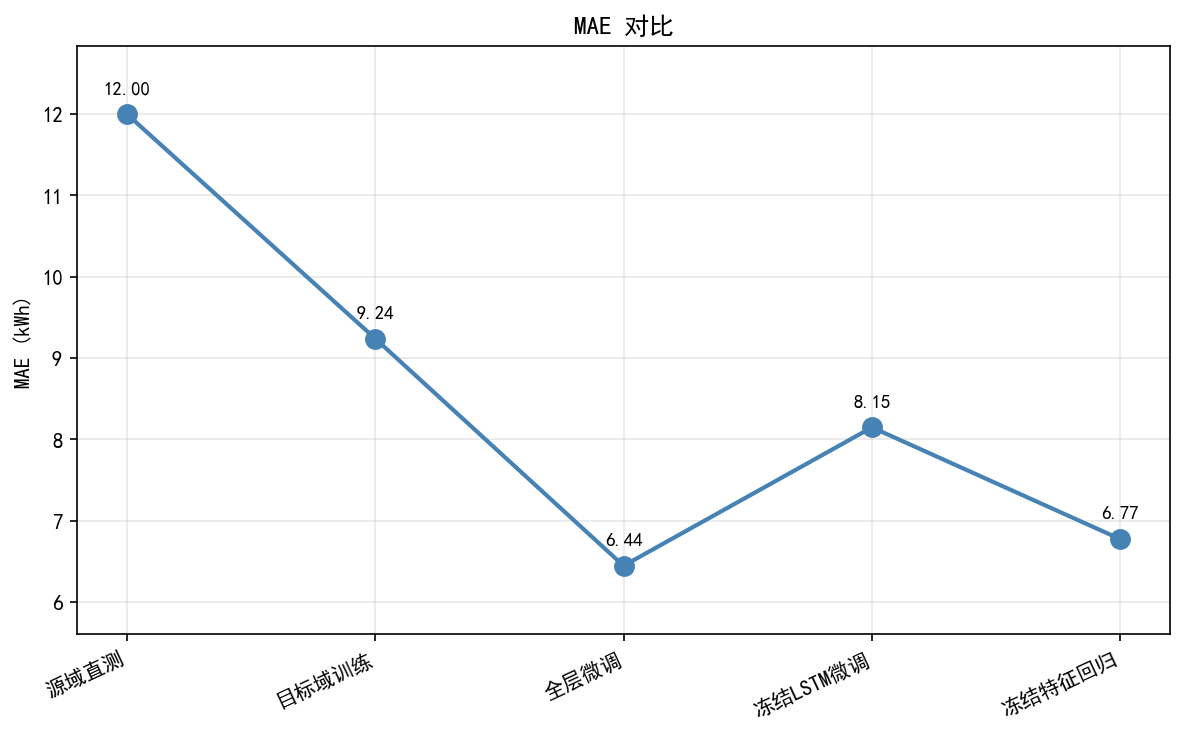

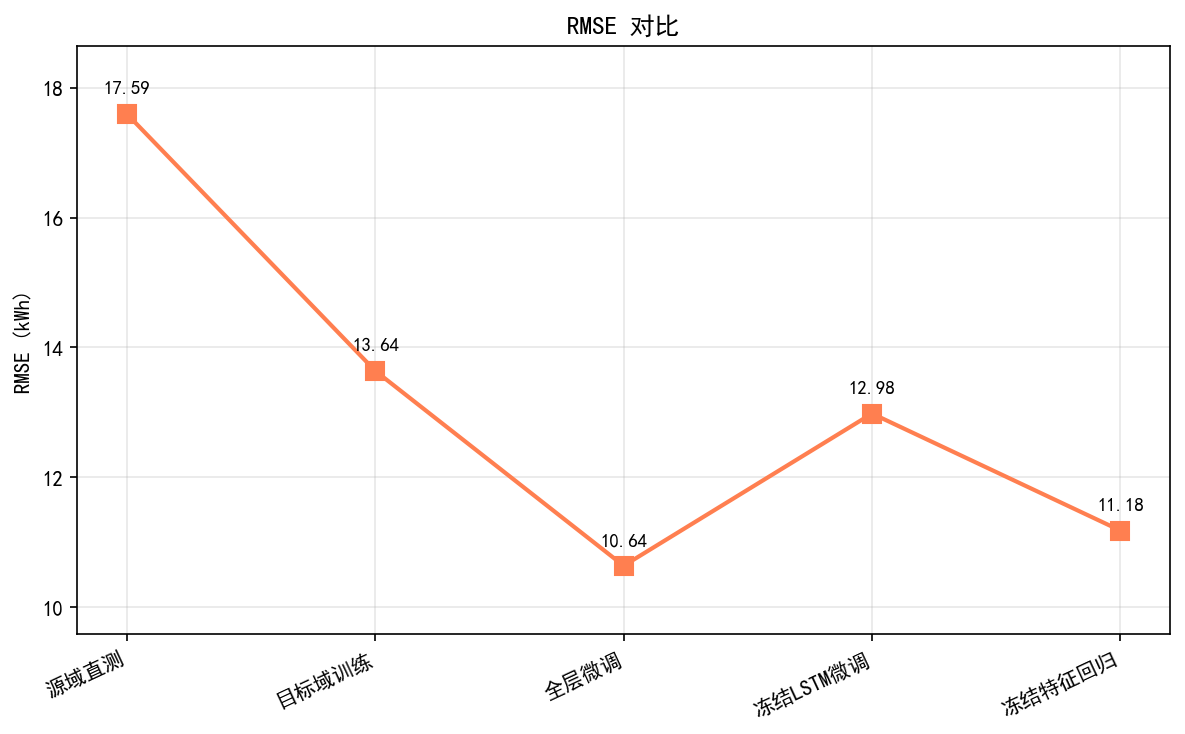

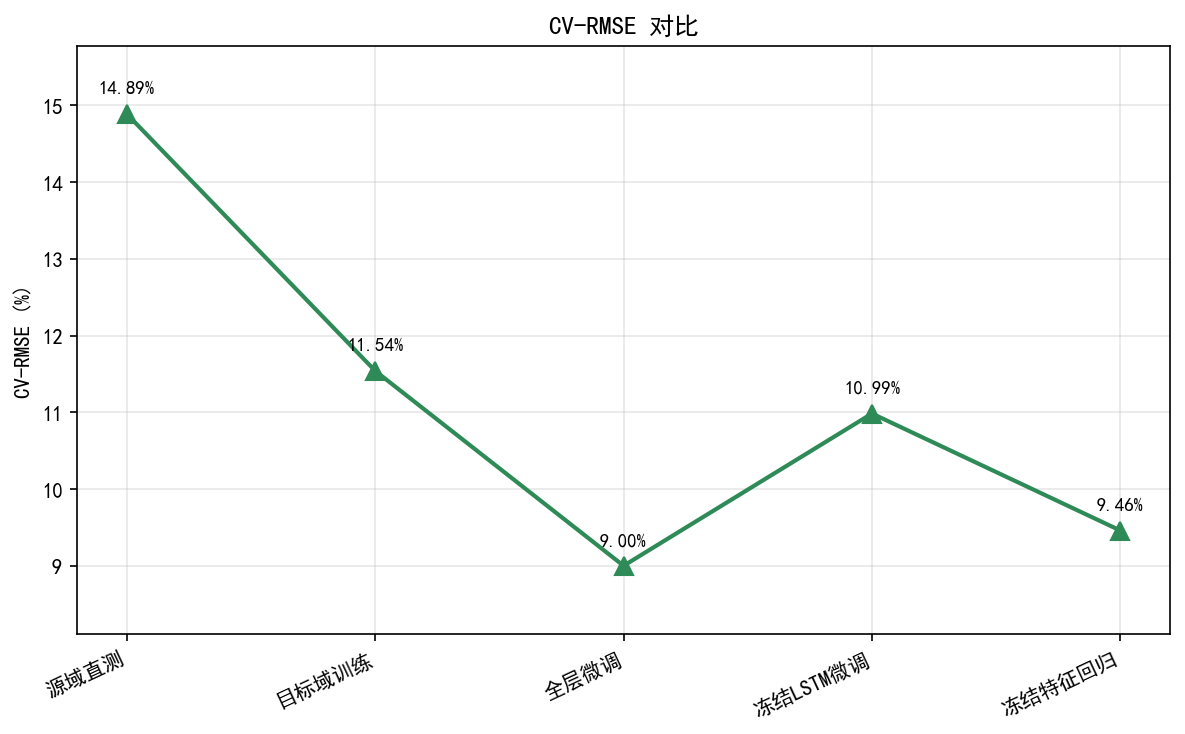

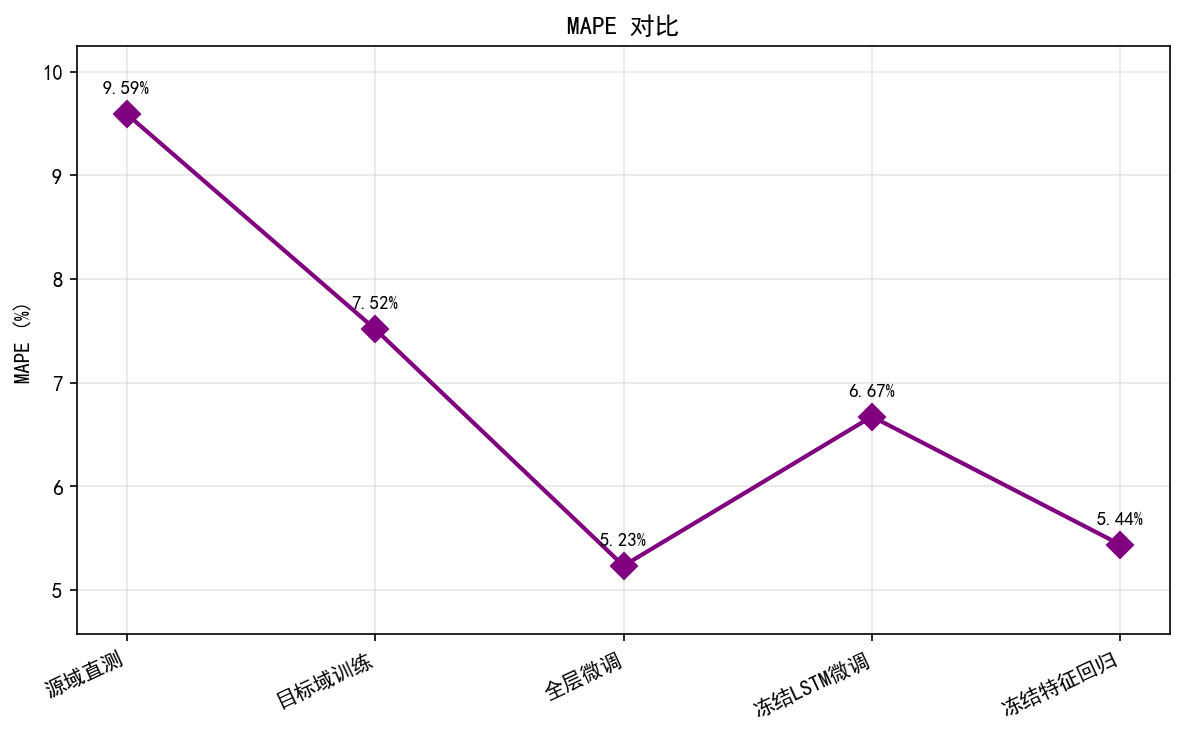

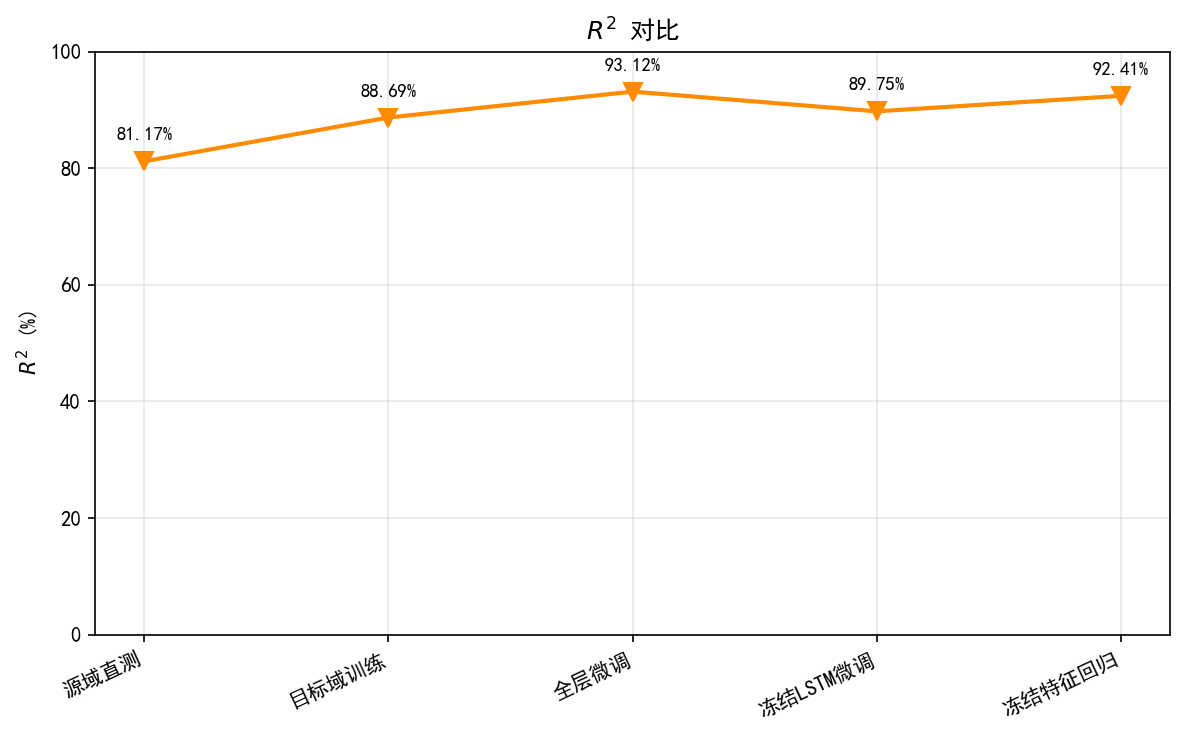

In [6]:
# 加载迁移学习结果
results_path = BASE_DIR / 'transfer_learning_strategy_mean_metrics.csv'

if results_path.exists():
    results_df = pd.read_csv(results_path)
    print(results_df.to_string(index=False))

    strategies = results_df['策略'].tolist()
    x = range(len(strategies))
    metric_configs = [
        {
            'column': 'MAE',
            'ylabel': 'MAE (kWh)',
            'title': 'MAE 对比',
            'color': 'steelblue',
            'marker': 'o',
            'suffix': '',
            'scale': 1,
            'filename': '迁移学习_MAE对比.png',
        },
        {
            'column': 'RMSE',
            'ylabel': 'RMSE (kWh)',
            'title': 'RMSE 对比',
            'color': 'coral',
            'marker': 's',
            'suffix': '',
            'scale': 1,
            'filename': '迁移学习_RMSE对比.png',
        },
        {
            'column': 'CV-RMSE',
            'ylabel': 'CV-RMSE (%)',
            'title': 'CV-RMSE 对比',
            'color': 'seagreen',
            'marker': '^',
            'suffix': '%',
            'scale': 1,
            'filename': '迁移学习_CV-RMSE对比.png',
        },
        {
            'column': 'MAPE',
            'ylabel': 'MAPE (%)',
            'title': 'MAPE 对比',
            'color': 'purple',
            'marker': 'D',
            'suffix': '%',
            'scale': 1,
            'filename': '迁移学习_MAPE对比.png',
        },
        {
            'column': 'R2',
            'ylabel': '$R^2$ (%)',
            'title': '$R^2$ 对比',
            'color': 'darkorange',
            'marker': 'v',
            'suffix': '%',
            'scale': 100,
            'ylim': (0, 100),
            'filename': '迁移学习_R2对比.png',
        },
    ]

    for config in metric_configs:
        values = results_df[config['column']].values * config['scale']
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(
            x, values,
            color=config['color'], marker=config['marker'],
            linewidth=2, markersize=9,
        )
        for j, val in enumerate(values):
            ax.annotate(
                f"{val:.2f}{config['suffix']}", (j, val),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9,
            )
        ax.set_xticks(x)
        ax.set_xticklabels(strategies, rotation=25, ha='right')
        ax.set_ylabel(config['ylabel'])
        ax.set_title(config['title'])
        if 'ylim' in config:
            ax.set_ylim(*config['ylim'])
        else:
            vmin, vmax = values.min(), values.max()
            vrange = vmax - vmin
            if vrange == 0:
                margin = max(abs(vmin) * 0.1, 1)
                ax.set_ylim(vmin - margin, vmax + margin)
            else:
                ax.set_ylim(vmin - 0.15 * vrange, vmax + 0.15 * vrange)
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(FIGURES_DIR / config['filename'], dpi=150, bbox_inches='tight')
        plt.show()
else:
    print(f"未找到迁移学习结果文件: {results_path}")
    print("请先运行 transfer_learning.ipynb")

## 四、输出文件说明

只有迁移学习结果图保存到 `data/figures/` 目录；其它可视化只在 notebook 中输出。

| 文件 | 说明 |
|------|------|
| `迁移学习_MAE对比.png` | 迁移学习策略 MAE 对比 |
| `迁移学习_RMSE对比.png` | 迁移学习策略 RMSE 对比 |
| `迁移学习_CV-RMSE对比.png` | 迁移学习策略 CV-RMSE 对比 |
| `迁移学习_MAPE对比.png` | 迁移学习策略 MAPE 对比 |
| `迁移学习_R2对比.png` | 迁移学习策略 R2 对比 |